# Middleware: Human In The Loop
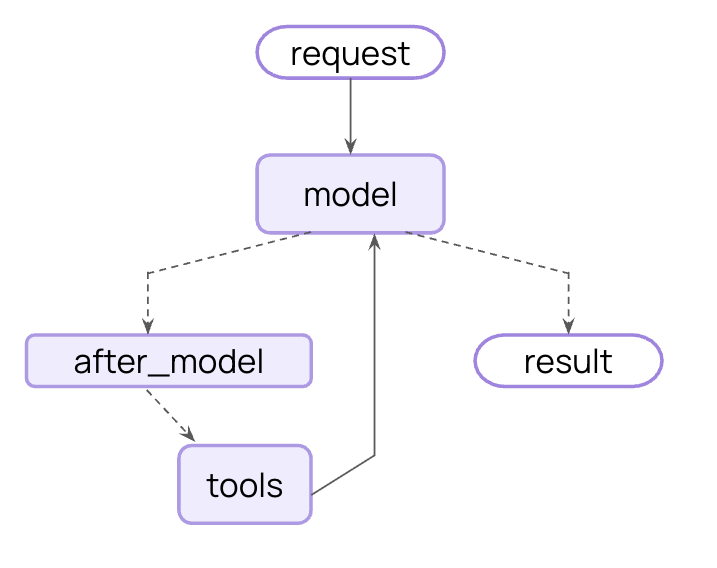



## Setup

In [1]:
import os, httpx
from dotenv import load_dotenv

# Load .env using absolute path (override=True to ensure it always loads fresh)
load_dotenv("/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/.env", override=True)

CA_BUNDLE = "/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = CA_BUNDLE
os.environ["REQUESTS_CA_BUNDLE"] = CA_BUNDLE

# Create a custom httpx client with the CA bundle
http_client = httpx.Client(verify=CA_BUNDLE)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0, http_client=http_client)

In [3]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

In [4]:
from dataclasses import dataclass

@dataclass
class RuntimeContext:
    db: SQLDatabase

In [5]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime


@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db
    
    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

In [6]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
- If the database is offline, ask user to try again later without further comment.
"""

## Middleware

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model=llm,
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    checkpointer=InMemorySaver(),
    context_schema=RuntimeContext,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={"execute_sql": {"allowed_decisions": ["approve", "reject"]}},
        ),
    ],
)

In [8]:
from langgraph.types import Command

question = "What are the names of all the employees?"

config = {"configurable": {"thread_id": "1"}}

result = agent.invoke(
    {"messages": [{"role": "user", "content": question}]},
    config=config,
    context=RuntimeContext(db=db)
)

if "__interrupt__" in result:
    description = result['__interrupt__'][-1].value['action_requests'][-1]['description']
    print(f"\033[1;3;31m{80 * '-'}\033[0m")
    print(
        f"\033[1;3;31m Interrupt:{description}\033[0m"
    )

    result = agent.invoke(
        Command(
            resume={
                "decisions": [{"type": "reject", "message": "the database is offline."}]
            }
        ),
        config=config,  # Same thread ID to resume the paused conversation
        context=RuntimeContext(db=db),
    )
    print(f"\033[1;3;31m{80 * '-'}\033[0m")

print(result["messages"][-1].content)

--------------------------------------------------------------------------------
 Interrupt:Tool execution requires approval

Tool: execute_sql
Args: {'query': 'SELECT name FROM employees'}
--------------------------------------------------------------------------------
I apologize, but I'm unable to retrieve the information as the database is currently offline. Please try again later.


In [9]:
config = {"configurable": {"thread_id": "2"}}

result = agent.invoke(
    {"messages": [{"role": "user", "content": question}]},
    config=config,
    context=RuntimeContext(db=db)
)

while "__interrupt__" in result:
    description = result['__interrupt__'][-1].value['action_requests'][-1]['description']
    print(f"\033[1;3;31m{80 * '-'}\033[0m")
    print(
        f"\033[1;3;31m Interrupt:{description}\033[0m"
    )
    
    result = agent.invoke(
        Command(
            resume={"decisions": [{"type": "approve"}]}
        ),
        config=config,  # Same thread ID to resume the paused conversation
        context=RuntimeContext(db=db),
    )

for msg in result["messages"]:
    msg.pretty_print()

--------------------------------------------------------------------------------
 Interrupt:Tool execution requires approval

Tool: execute_sql
Args: {'query': 'SELECT name FROM employees'}
================================ Human Message =================================

What are the names of all the employees?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (ztr6bxqzg)
 Call ID: ztr6bxqzg
  Args:
    query: SELECT name FROM employees
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: employees
[SQL: SELECT name FROM employees]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message ==================================

I don't have access to employees information.
